In [ ]:
# CELL 1: Install and import required libraries

!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost mlflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")

print("✅ Libraries installed and imported successfully")
print("✅ Environment is ready for Smart Parking Prediction System")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [ ]:
# CELL 2: Create FAST SINPA-inspired synthetic realistic dataset

import random

random.seed(42)
np.random.seed(42)

num_lots = 60         # smaller, faster
days = 60             # 2 months
time_slots = 24       # hourly data instead of 15-min slots

planning_areas = list(range(12))
utilization_types = list(range(5))

records = []

for lot_id in range(num_lots):
    planning_area = random.choice(planning_areas)
    utilization_type = random.choice(utilization_types)

    road_density = np.clip(np.random.normal(0, 1), -3, 3)
    latitude = np.clip(np.random.normal(0, 1), -3, 3)
    longitude = np.clip(np.random.normal(0, 1), -3, 3)

    capacity = random.randint(80, 250)

    for day in range(days):
        weekday = day % 7
        is_holiday = 1 if random.random() < 0.08 else 0

        for time_of_day in range(time_slots):
            temperature = np.clip(np.random.normal(0, 1), -3, 3)
            humidity = np.clip(np.random.normal(0, 1), -3, 3)
            windspeed = np.clip(np.random.normal(0, 1), -3, 3)

            morning_peak = 1 if time_of_day in [7, 8, 9, 10] else 0
            evening_peak = 1 if time_of_day in [17, 18, 19, 20] else 0
            weekend_effect = 1 if weekday in [5, 6] else 0

            base_occ = 0.35
            base_occ += 0.22 * morning_peak
            base_occ += 0.28 * evening_peak
            base_occ += 0.10 * weekend_effect
            base_occ += 0.08 * is_holiday
            base_occ += (planning_area / 11) * 0.08
            base_occ += (utilization_type / 4) * 0.05
            base_occ -= 0.03 * windspeed
            base_occ += 0.02 * humidity
            base_occ += 0.02 * temperature
            base_occ += np.random.normal(0, 0.05)

            occupancy_rate = np.clip(base_occ, 0.05, 0.98)

            occupied_slots = int(occupancy_rate * capacity)
            available_slots = capacity - occupied_slots

            records.append({
                'lot_id': lot_id,
                'parking_availability': available_slots,
                'time_of_day': time_of_day,
                'weekday': weekday,
                'is_holiday': is_holiday,
                'temperature': round(temperature, 3),
                'humidity': round(humidity, 3),
                'windspeed': round(windspeed, 3),
                'utilization_type': utilization_type,
                'planning_area': planning_area,
                'road_density': round(road_density, 3),
                'latitude': round(latitude, 3),
                'longitude': round(longitude, 3),
                'capacity': capacity,
                'occupied_slots': occupied_slots,
                'available_slots': available_slots,
                'occupancy_rate': round(occupancy_rate, 3)
            })

df = pd.DataFrame(records)

print("✅ Dataset created successfully")
print("✅ Shape:", df.shape)
display(df.head())

✅ Dataset created successfully
✅ Shape: (86400, 17)


,lot_id,parking_availability,time_of_day,weekday,is_holiday,temperature,humidity,windspeed,utilization_type,planning_area,road_density,latitude,longitude,capacity,occupied_slots,available_slots,occupancy_rate
0,0,41,0,0,0,1.523,-0.234,-0.234,0,10,0.497,-0.138,0.648,86,45,41,0.534
1,0,53,1,0,0,0.767,-0.469,0.543,0,10,0.497,-0.138,0.648,86,33,53,0.389
2,0,53,2,0,0,-0.466,0.242,-1.913,0,10,0.497,-0.138,0.648,86,33,53,0.389
3,0,58,3,0,0,-0.562,-1.013,0.314,0,10,0.497,-0.138,0.648,86,28,58,0.336
4,0,49,4,0,0,-1.412,1.466,-0.226,0,10,0.497,-0.138,0.648,86,37,49,0.434


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lot_id                86400 non-null  int64  
 1   parking_availability  86400 non-null  int64  
 2   time_of_day           86400 non-null  int64  
 3   weekday               86400 non-null  int64  
 4   is_holiday            86400 non-null  int64  
 5   temperature           86400 non-null  float64
 6   humidity              86400 non-null  float64
 7   windspeed             86400 non-null  float64
 8   utilization_type      86400 non-null  int64  
 9   planning_area         86400 non-null  int64  
 10  road_density          86400 non-null  float64
 11  latitude              86400 non-null  float64
 12  longitude             86400 non-null  float64
 13  capacity              86400 non-null  int64  
 14  occupied_slots        86400 non-null  int64  
 15

,lot_id,parking_availability,time_of_day,weekday,is_holiday,temperature,humidity,windspeed,utilization_type,planning_area,road_density,latitude,longitude,capacity,occupied_slots,available_slots,occupancy_rate
count,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000
mean,29.500000,79.697870,11.500000,2.900000,0.076389,0.000577,0.001541,-0.003648,1.733333,5.583333,0.034867,0.120983,-0.167017,166.883333,87.185463,79.697870,0.528426
std,17.318203,36.903637,6.922227,1.989149,0.265621,0.995264,0.994346,1.000381,1.314880,3.446234,0.836406,1.004851,1.041721,53.067589,36.836996,36.903637,0.147028
min,0.000000,2.000000,0.000000,0.000000,0.000000,-3.000000,-3.000000,-3.000000,0.000000,0.000000,-1.983000,-1.678000,-2.560000,82.000000,15.000000,2.000000,0.154000
25%,14.750000,50.000000,5.750000,1.000000,0.000000,-0.673000,-0.668000,-0.682000,1.000000,2.750000,-0.533750,-0.696000,-0.778000,116.500000,59.000000,50.000000,0.414000
50%,29.500000,75.000000,11.500000,3.000000,0.000000,-0.002000,0.007000,-0.008000,2.000000,5.000000,0.143000,0.105500,-0.288500,172.500000,81.000000,75.000000,0.501000
75%,44.250000,108.000000,17.250000,5.000000,0.000000,0.672000,0.679000,0.668000,3.000000,8.250000,0.550000,0.808750,0.504750,214.500000,109.000000,108.000000,0.640000
max,59.000000,205.000000,23.000000,6.000000,1.000000,3.000000,3.000000,3.000000,4.000000,11.000000,2.098000,2.697000,2.432000,248.000000,241.000000,205.000000,0.980000


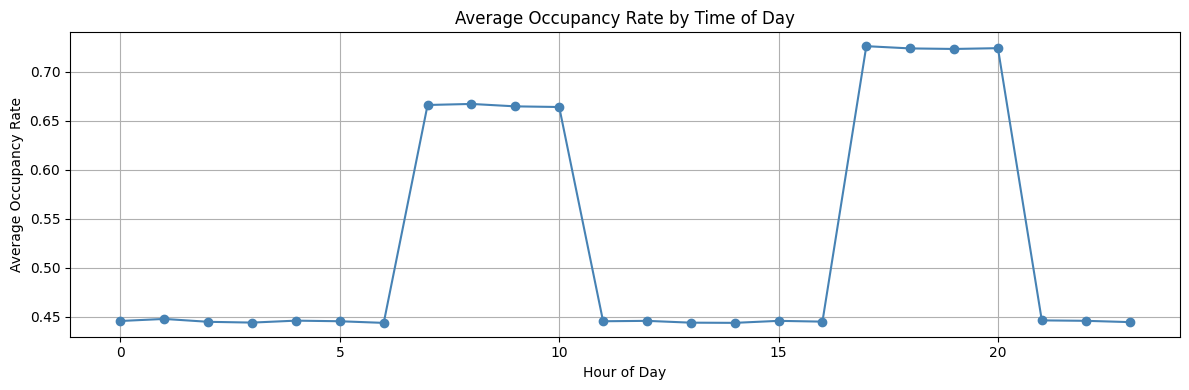

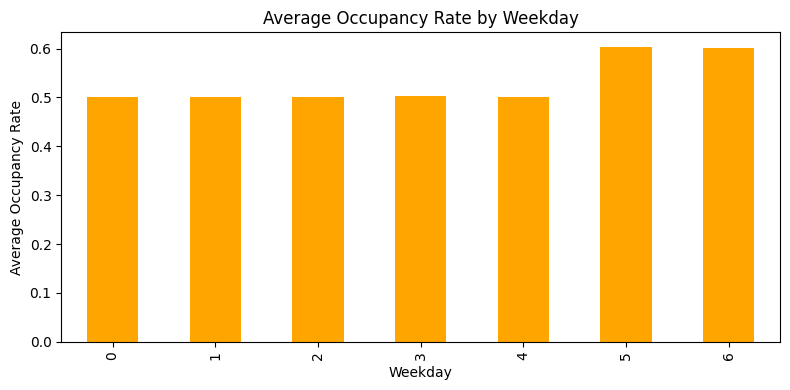

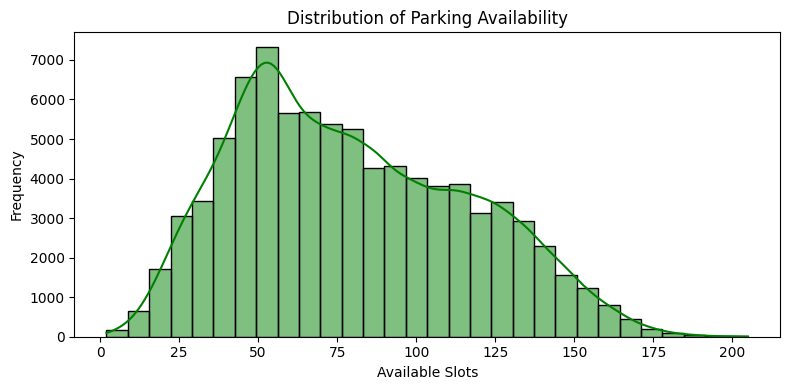

✅ EDA complete


In [ ]:
# CELL 3: Data understanding + EDA

print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
display(df.describe())

# Average occupancy by hour
plt.figure(figsize=(12, 4))
avg_by_hour = df.groupby('time_of_day')['occupancy_rate'].mean()
plt.plot(avg_by_hour.index, avg_by_hour.values, marker='o', color='steelblue')
plt.title('Average Occupancy Rate by Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Occupancy Rate')
plt.grid(True)
plt.tight_layout()
plt.show()

# Average occupancy by weekday
plt.figure(figsize=(8, 4))
df.groupby('weekday')['occupancy_rate'].mean().plot(kind='bar', color='orange')
plt.title('Average Occupancy Rate by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Occupancy Rate')
plt.tight_layout()
plt.show()

# Parking availability distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['parking_availability'], bins=30, kde=True, color='green')
plt.title('Distribution of Parking Availability')
plt.xlabel('Available Slots')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("✅ EDA complete")

In [ ]:
# CELL 4: Feature selection and train-test split

features = [
    'time_of_day',
    'weekday',
    'is_holiday',
    'temperature',
    'humidity',
    'windspeed',
    'utilization_type',
    'planning_area',
    'road_density',
    'latitude',
    'longitude',
    'capacity',
    'occupied_slots'
]

target = 'occupancy_rate'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Feature selection completed")
print("Features used:", features)
print("\n✅ Train-Test Split completed")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

✅ Feature selection completed
Features used: ['time_of_day', 'weekday', 'is_holiday', 'temperature', 'humidity', 'windspeed', 'utilization_type', 'planning_area', 'road_density', 'latitude', 'longitude', 'capacity', 'occupied_slots']

✅ Train-Test Split completed
X_train shape: (69120, 13)
X_test shape : (17280, 13)
y_train shape: (69120,)
y_test shape : (17280,)


In [ ]:
# CELL 5: Train models with MLflow tracking

mlflow.set_experiment("SmartParkingMLOps")

models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "LinearRegression": LinearRegression()
}

results = {}

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        mlflow.log_param("model", model_name)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("R2", r2)

        mlflow.sklearn.log_model(model, model_name)

        results[model_name] = {
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "model": model
        }

        print(f"✅ {model_name} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

print("\n✅ All models trained and logged to MLflow!")

2026/05/06 15:00:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/06 15:00:24 INFO mlflow.store.db.utils: Updating database tables
2026/05/06 15:00:26 INFO mlflow.tracking.fluent: Experiment with name 'SmartParkingMLOps' does not exist. Creating a new experiment.
2026/05/06 15:01:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 15:01:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ RandomForest -> RMSE: 0.0026 | MAE: 0.0020 | R²: 0.9997


2026/05/06 15:01:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 15:01:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 15:01:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 15:01:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

✅ XGBoost -> RMSE: 0.0036 | MAE: 0.0028 | R²: 0.9994
✅ LinearRegression -> RMSE: 0.0441 | MAE: 0.0321 | R²: 0.9111

✅ All models trained and logged to MLflow!


✅ Best Model: RandomForest
   RMSE : 0.0026
   MAE  : 0.0020
   R²   : 0.9997


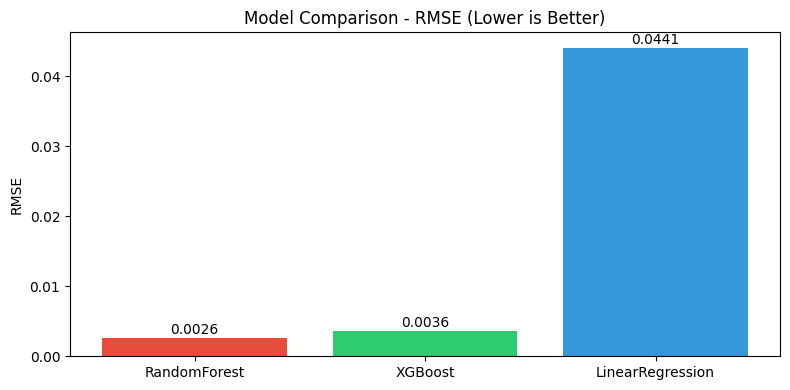

In [ ]:
# CELL 6: Select best model and show comparison

best_model_name = min(results, key=lambda x: results[x]['RMSE'])
best_model = results[best_model_name]['model']

print(f"✅ Best Model: {best_model_name}")
print(f"   RMSE : {results[best_model_name]['RMSE']:.4f}")
print(f"   MAE  : {results[best_model_name]['MAE']:.4f}")
print(f"   R²   : {results[best_model_name]['R2']:.4f}")

# Comparison bar chart
model_names = list(results.keys())
rmse_vals = [results[m]['RMSE'] for m in model_names]

plt.figure(figsize=(8, 4))
bars = plt.bar(model_names, rmse_vals, color=['#e74c3c', '#2ecc71', '#3498db'])
plt.title('Model Comparison - RMSE (Lower is Better)')
plt.ylabel('RMSE')

for bar, val in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005, f'{val:.4f}', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# CELL 7: Save best model and test prediction

import pickle

with open('best_parking_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"✅ Best model ({best_model_name}) saved as best_parking_model.pkl")

sample_input = pd.DataFrame([{
    'time_of_day': 18,
    'weekday': 2,
    'is_holiday': 0,
    'temperature': 0.5,
    'humidity': 0.2,
    'windspeed': -0.1,
    'utilization_type': 1,
    'planning_area': 5,
    'road_density': 0.3,
    'latitude': 1.2,
    'longitude': 0.4,
    'capacity': 150,
    'occupied_slots': 92
}])

prediction = best_model.predict(sample_input)[0]
available_slots = round(prediction, 2)

print("\n✅ Sample Prediction:")
print("   Input: Evening peak hour | Weekday | Moderate occupancy")
print(f"   Predicted Parking Availability : {available_slots}")

✅ Best model (RandomForest) saved as best_parking_model.pkl

✅ Sample Prediction:
   Input: Evening peak hour | Weekday | Moderate occupancy
   Predicted Parking Availability : 0.62


In [13]:
# CELL 8: Save and download the best model

import pickle
from google.colab import files

with open('best_parking_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ best_parking_model.pkl saved successfully")

files.download('best_parking_model.pkl')

✅ best_parking_model.pkl saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>